# 03 — Modelo econométrico final e Inefficiency Score

## Sprint 13A.1 — Multi-League Modeling Evaluation

### Release v1.2.1 (Experimental)

Este notebook evalúa el impacto de la expansión multi-liga sobre el rendimiento del modelo econométrico manteniendo constantes la especificación, las variables y la estrategia de validación temporal.

## Objetivo del notebook

En la decisión metodológica mantenida en Sprint 13A.1 el proyecto ya no se limita a estimar valor de mercado, sino que separa explícitamente:

```text
Historical Evaluation Layer
↓
Current Scouting Layer
↓
Player Intelligence Layer
↓
Decision Support Layer
```

Por tanto, este notebook pertenece principalmente a la **Historical Evaluation Layer**.

Su función es:

- construir un benchmark econométrico interpretable;
- estimar el valor esperado de mercado;
- analizar drivers estructurales de valoración;
- generar un Inefficiency Score exploratorio sobre test histórico;
- servir como referencia metodológica frente al pipeline productivo de Machine Learning.

La generación operativa de shortlists actuales en en la arquitectura actual del proyecto se realiza posteriormente mediante:

```text
Tuned XGBoost
↓
Scoring Engine
↓
Risk Framework
↓
Current Scouting Layer
↓
Player Intelligence Layer
```


## 1. Objetivo analítico y decisión de negocio

El objetivo econométrico es estimar el valor de mercado esperado de un jugador joven a partir de:

- edad;
- volumen competitivo;
- producción ofensiva;
- contexto de liga;
- posición;
- variables de rendimiento disponibles.

Desde el punto de vista de negocio, el objetivo no es únicamente minimizar error predictivo, sino construir una referencia interpretable que permita detectar discrepancias entre valor observado y valor esperado.

Estas discrepancias alimentan una primera noción de:

```text
ineficiencia de mercado
```

No obstante, en la arquitectura arquitectura v1.2.1 — Multi-League Modeling Evaluation, el modelo econométrico se interpreta como benchmark explicativo. Las recomendaciones operativas actuales se generan en la capa de Machine Learning y Scouting Intelligence.


## 2. Especificación econométrica

La especificación base estima:

```python
log_market_value_eur ~
age +
log_minutes_played +
goals_per90 +
assists_per90 +
league FE +
position FE
```

Decisión metodológica v1.0.0:

- se mantiene `log_market_value_eur` como target principal;
- se utilizan efectos fijos de liga y posición;
- se evita que el modelo final dependa de efectos fijos de temporada para predecir temporadas futuras;
- la temporada se conserva como variable descriptiva y de split temporal;
- la evaluación se realiza con validación temporal estricta.

Esta decisión es coherente con Sprint 10, donde la temporada 2025-2026 se reserva para la capa operativa de scouting actual.


In [1]:
# ============================================================
# 1. Imports y configuración
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

TARGET = "log_market_value_eur"
RANDOM_STATE = 42

TRAIN_SEASONS = [
    "2019-2020",
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]

TEST_SEASON = "2024-2025"
CURRENT_SCOUTING_SEASON = "2025-2026"


In [2]:
# ============================================================
# 2. Rutas del proyecto
# ============================================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "player_season_modeling_v13a.parquet"
OUTPUT_DIR = PROJECT_ROOT / "reports" / "sprint_13a1" / "econometric"
MODEL_OUTPUT_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "sprint_13a1"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

PROJECT_ROOT: c:\Users\manue\Projects\market-value-football-tfm
DATA_PATH: c:\Users\manue\Projects\market-value-football-tfm\data\processed\player_season_modeling_v13a.parquet
OUTPUT_DIR: c:\Users\manue\Projects\market-value-football-tfm\reports\sprint_13a1\econometric


## 3. Carga y validación del dataset modelizable

El dataset modelizable procede de:

```text
data/processed/player_season_modeling_v13a.parquet
```

En el Sprint 13A.1 — Multi-League Modeling Evaluation debe contener la cobertura completa:

```text
2019-2020 → 2025-2026 | 11 ligas | 5.527 observaciones | 2.867 jugadores
```

Este notebook utiliza únicamente las temporadas históricas para la validación econométrica y deja 2025-2026 fuera del entrenamiento/test, al pertenecer a la Current Scouting Layer.


In [3]:
# ============================================================
# 3. Carga del dataset
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No existe {DATA_PATH}. Ejecuta antes src.data.build_modeling_dataset."
    )

df = pd.read_parquet(DATA_PATH)

print("Dataset cargado")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Players: {df['player_name_fbref'].nunique() if 'player_name_fbref' in df.columns else 'n/a'}")
print(f"Seasons: {df['season'].min()} - {df['season'].max()}")
df.head()

Dataset cargado
Rows: 5,527
Columns: 54
Players: 2867
Seasons: 2019-2020 - 2025-2026


,player_name_fbref,club,league,season,season_start_year_fbref,position,position_group,age_fbref,matches_played,starts,minutes_played,nineties,goals,assists,g_a,goals_minus_pk,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_per90,assists_per90,g_a_per90,goals_minus_pk_per90,g_a_minus_pk_per90,player_name_norm,player_id_tm,player_name_tm,season_start_year_tm,valuation_date,market_value_eur,log_market_value_eur,market_value_prev_eur,market_value_next_eur,market_value_growth_1y,delta_log_market_value_1y,age_tm,date_of_birth,nationality,position_tm,sub_position_tm,foot,height_in_cm,current_club_name_tm,current_club_id_tm,competition_id_tm,source,matching_method,matching_confidence,age_diff,club_score,matching_status,season_start_year,age
0,Marvin Young,Sparta Rotterdam,Eredivisie,2025-2026,2025,DF,DEF,19.0000,33,33,2970,33.0000,0,1,1,0,0,0,7,0,0.0000,0.0300,0.0300,0.0000,0.0300,marvin young,"928,592.0000",Marvin Young,"2,025.0000",2025-10-02,"4,000,000.0000",15.2018,"2,500,000.0000","4,000,000.0000",0.0000,0.0000,20.0000,2005-10-02 00:00:00,Netherlands,Defender,Centre-Back,right,182.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.0000,100.0000,True,2025,20.0000
1,Tyrese Campbell,Stoke City,Championship,2022-2023,2022,"FW,MF",MID,22.0000,41,30,2656,29.5000,9,5,14,9,0,0,4,0,0.3000,0.1700,0.4700,0.3000,0.4700,tyrese campbell,"382,554.0000",Tyrese Campbell,"2,022.0000",2022-09-14,"3,000,000.0000",14.9141,"4,000,000.0000","3,000,000.0000",0.0000,0.0000,22.7132,1999-12-28 00:00:00,England,Attack,Centre-Forward,left,185.0000,Stoke City,512.0000,GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.7132,100.0000,True,2022,22.7132
2,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2022-2023,2022,MF,MID,20.0000,34,29,2651,29.5000,4,2,6,4,0,0,2,0,0.1400,0.0700,0.2000,0.1400,0.2000,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,022.0000",2022-11-11,"1,200,000.0000",13.9978,"800,000.0000","3,000,000.0000",1.5000,0.9163,21.2731,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2731,100.0000,True,2022,21.2731
3,Teden Mengi,Luton Town,Premier League,2023-2024,2023,DF,DEF,21.0000,30,28,2469,27.4000,1,0,1,1,0,0,3,0,0.0400,0.0000,0.0400,0.0400,0.0400,teden mengi,"548,470.0000",Teden Mengi,"2,023.0000",2023-12-19,"7,000,000.0000",15.7614,"2,000,000.0000","12,000,000.0000",0.7143,0.5390,21.6372,2002-04-30 00:00:00,England,Defender,Centre-Back,right,186.0000,Luton Town,"1,031.0000",GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.6372,100.0000,True,2023,21.6372
4,Harry Clarke,Ipswich Town,Championship,2023-2024,2023,DF,DEF,22.0000,35,25,2361,26.2000,1,1,2,1,0,0,7,0,0.0400,0.0400,0.0800,0.0400,0.0800,harry clarke,"528,892.0000",Harry Clarke,"2,023.0000",2023-12-21,"2,500,000.0000",14.7318,"1,400,000.0000","4,000,000.0000",0.6000,0.4700,22.8036,2001-03-02 00:00:00,England,Defender,Right-Back,right,180.0000,Ipswich Town,677.0000,GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.8036,100.0000,True,2023,22.8036


In [4]:
print("Dataset cargado")
print(f"Rows: {len(df):,}")
print(f"Players: {df['player_id_tm'].nunique():,}")
print(f"Leagues: {df['league'].nunique():,}")
print(f"Seasons: {df['season'].nunique():,}")
print(sorted(df["league"].dropna().unique()))

Dataset cargado
Rows: 5,527
Players: 2,867
Leagues: 11
Seasons: 7
['Austrian Bundesliga', 'Belgian Pro League', 'Bundesliga', 'Championship', 'Eredivisie', 'LaLiga', 'Liga Portugal', 'Ligue 1', 'Premier League', 'Serie A', 'Spanish Segunda División']


In [5]:
# ============================================================
# 4. Normalización de columnas auxiliares
# ============================================================

model_df = df.copy()

# Nombre de jugador para rankings
if "player_name" not in model_df.columns:
    if "player_name_fbref" in model_df.columns:
        model_df["player_name"] = model_df["player_name_fbref"]
    elif "player_name_tm" in model_df.columns:
        model_df["player_name"] = model_df["player_name_tm"]

# Edad consolidada
if "age" not in model_df.columns:
    if "age_tm" in model_df.columns:
        model_df["age"] = model_df["age_tm"]
    elif "age_fbref" in model_df.columns:
        model_df["age"] = model_df["age_fbref"]

# Log de minutos
if "minutes_played" not in model_df.columns:
    raise KeyError("Falta minutes_played, variable mínima para el modelo.")

model_df["log_minutes_played"] = np.log1p(model_df["minutes_played"])

required = [TARGET, "market_value_eur", "season", "league", "position_group", "age", "log_minutes_played"]
missing = [c for c in required if c not in model_df.columns]
if missing:
    raise KeyError(f"Faltan columnas obligatorias: {missing}")

print("Columnas mínimas validadas correctamente")

Columnas mínimas validadas correctamente


## 4. Feature engineering deportivo

Se incorporan variables deportivas disponibles en el dataset. Cuando existen métricas suficientes, se construyen índices normalizados por `position_group` y `league` para mejorar comparabilidad entre roles y contextos competitivos.

La lógica es conservadora: no se fuerza ninguna variable inexistente. El notebook detecta columnas disponibles y ajusta la especificación final automáticamente.

In [6]:
# ============================================================
# 5. Feature engineering robusto según columnas disponibles
# ============================================================

PERFORMANCE_CANDIDATES = [
    "goals_per90",
    "assists_per90",
    "shots_per90",
    "progressive_passes_per90",
    "progressive_carries_per90",
    "tackles_per90",
    "interceptions_per90",
]

available_perf = [c for c in PERFORMANCE_CANDIDATES if c in model_df.columns]
print("Variables deportivas disponibles:", available_perf)

for col in available_perf:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")


def safe_zscore(s: pd.Series) -> pd.Series:
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / std

# Z-scores por posición y liga para controlar comparabilidad contextual
for col in available_perf:
    z_col = f"z_{col}"
    model_df[z_col] = (
        model_df
        .groupby(["position_group", "league"], dropna=False)[col]
        .transform(safe_zscore)
    )

# Índices interpretables, solo si existen los componentes necesarios
if {"z_goals_per90", "z_shots_per90"}.issubset(model_df.columns):
    model_df["finishing_index"] = model_df[["z_goals_per90", "z_shots_per90"]].mean(axis=1)

if {"z_assists_per90", "z_progressive_passes_per90"}.issubset(model_df.columns):
    model_df["playmaking_index"] = model_df[["z_assists_per90", "z_progressive_passes_per90"]].mean(axis=1)

if {"z_progressive_passes_per90", "z_progressive_carries_per90"}.issubset(model_df.columns):
    model_df["progression_index"] = model_df[["z_progressive_passes_per90", "z_progressive_carries_per90"]].mean(axis=1)

if {"z_tackles_per90", "z_interceptions_per90"}.issubset(model_df.columns):
    model_df["defensive_index"] = model_df[["z_tackles_per90", "z_interceptions_per90"]].mean(axis=1)

created_indexes = [c for c in ["finishing_index", "playmaking_index", "progression_index", "defensive_index"] if c in model_df.columns]
print("Índices creados:", created_indexes)

Variables deportivas disponibles: ['goals_per90', 'assists_per90']
Índices creados: []


## 5.1 Nota metodológica sobre features avanzadas

El notebook crea índices interpretables únicamente cuando las columnas necesarias existen en el dataset.

Esto evita romper la reproducibilidad cuando determinadas métricas avanzadas aún no forman parte del pipeline operativo.

Sprint 10.2 documenta precisamente esta limitación mediante la auditoría de métricas avanzadas de FBref, dejando su integración completa para el futuro Advanced Football Radar.


## 5. Split temporal train/test

La partición temporal se define de forma explícita para evitar incoherencias con Sprint 10:

```text
Train:
2019-2020 → 2023-2024

Test histórico:
2024-2025

Current Scouting Layer:
2025-2026
```

La temporada 2025-2026 queda excluida del entrenamiento y de la evaluación del modelo econométrico en este notebook.

Esto evita mezclar:

```text
evaluación histórica
```

con

```text
scouting operativo actual
```


In [7]:
# ============================================================
# 6. Muestra econométrica y split temporal
# ============================================================

BASE_NUMERIC_FEATURES = [
    "age",
    "log_minutes_played",
]

# Mantener producción ofensiva directa si está disponible
for c in ["goals_per90", "assists_per90"]:
    if c in model_df.columns:
        BASE_NUMERIC_FEATURES.append(c)

ADVANCED_FEATURES = [
    c for c in ["finishing_index", "playmaking_index", "progression_index", "defensive_index"]
    if c in model_df.columns
]

FINAL_NUMERIC_FEATURES = BASE_NUMERIC_FEATURES + ADVANCED_FEATURES

# En el modelo predictivo final se evitan season fixed effects porque
# una temporada futura no está observada durante el entrenamiento.
CATEGORICAL_FEATURES = ["league", "position_group"]

needed = [TARGET, "market_value_eur", "season"] + FINAL_NUMERIC_FEATURES + CATEGORICAL_FEATURES
model_df = model_df.dropna(subset=needed).copy()

train = model_df[model_df["season"].isin(TRAIN_SEASONS)].copy()
test = model_df[model_df["season"] == TEST_SEASON].copy()
current_scouting = model_df[model_df["season"] == CURRENT_SCOUTING_SEASON].copy()

if train.empty or test.empty:
    raise ValueError("El split temporal ha generado train o test vacío. Revisa las etiquetas de temporada.")

print("Features finales:", FINAL_NUMERIC_FEATURES)
print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Current scouting rows: {len(current_scouting):,}")

print("Train seasons:", sorted(train["season"].unique()))
print("Test seasons:", sorted(test["season"].unique()))
print("Current scouting season:", sorted(current_scouting["season"].unique()))


Features finales: ['age', 'log_minutes_played', 'goals_per90', 'assists_per90']
Train rows: 3,940
Test rows: 776
Current scouting rows: 811
Train seasons: ['2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024']
Test seasons: ['2024-2025']
Current scouting season: ['2025-2026']


In [8]:
# Descriptivo de la muestra final
summary_sample = pd.DataFrame({
    "rows": [len(model_df)],
    "players": [model_df["player_name"].nunique() if "player_name" in model_df.columns else np.nan],
    "train_rows": [len(train)],
    "test_rows": [len(test)],
    "n_leagues": [model_df["league"].nunique()],
    "n_seasons": [model_df["season"].nunique()],
})
summary_sample

,rows,players,train_rows,test_rows,n_leagues,n_seasons
0,5527,2867,3940,776,11,7


## 6. Funciones de modelización y evaluación

Se construyen matrices de diseño consistentes entre train y test. Las dummies del test se alinean con las columnas del train para evitar errores cuando alguna categoría no aparece en una partición.

In [9]:
# ============================================================
# 7. Funciones auxiliares
# ============================================================

def build_X(data: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]) -> pd.DataFrame:
    X = data[numeric_features + categorical_features].copy()
    X = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=float)
    X = sm.add_constant(X, has_constant="add")
    return X.astype(float)


def align_X(X_new: pd.DataFrame, X_train: pd.DataFrame) -> pd.DataFrame:
    return X_new.reindex(columns=X_train.columns, fill_value=0.0).astype(float)


def fit_ols_hc3(train_df: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]):
    X_train = build_X(train_df, numeric_features, categorical_features)
    y_train = train_df[TARGET].astype(float)
    fitted = sm.OLS(y_train, X_train).fit(cov_type="HC3")
    return fitted, X_train


def predict_with_design(fitted, data: pd.DataFrame, X_train: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]) -> np.ndarray:
    X_new = build_X(data, numeric_features, categorical_features)
    X_new = align_X(X_new, X_train)
    return fitted.predict(X_new)


def regression_metrics(y_true, y_pred, model_name: str, split: str) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "model": model_name,
        "split": split,
        "n": len(y_true),
        "MAE_log": mean_absolute_error(y_true, y_pred),
        "RMSE_log": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
    }

## 7. Modelos estimados

Se estiman tres modelos econométricos principales y un benchmark ingenuo:

- **M0 — Media de train**.
- **M1 — Modelo base sin efectos fijos**.
- **M2 — Modelo base con efectos fijos de liga y posición**.
- **M3 — Modelo final con variables avanzadas disponibles y efectos fijos de liga y posición**.

La variable `season` se utiliza para el split temporal, pero no como efecto fijo en el modelo final predictivo para evitar dependencia de categorías temporales no observadas en temporadas futuras.


In [10]:
# ============================================================
# 8. Estimación de modelos
# ============================================================

models = {}
metrics = []

# M0: media de train
m0_pred_train = np.repeat(train[TARGET].mean(), len(train))
m0_pred_test = np.repeat(train[TARGET].mean(), len(test))
metrics.append(regression_metrics(train[TARGET], m0_pred_train, "M0_mean_train", "train"))
metrics.append(regression_metrics(test[TARGET], m0_pred_test, "M0_mean_train", "test"))

# M1: base sin FE
m1_features = BASE_NUMERIC_FEATURES
m1, X1_train = fit_ols_hc3(train, m1_features, [])
models["M1_base_no_FE"] = (m1, X1_train, m1_features, [])

# M2: base + FE
m2, X2_train = fit_ols_hc3(train, BASE_NUMERIC_FEATURES, CATEGORICAL_FEATURES)
models["M2_base_FE"] = (m2, X2_train, BASE_NUMERIC_FEATURES, CATEGORICAL_FEATURES)

# M3: final + advanced features + FE
m3, X3_train = fit_ols_hc3(train, FINAL_NUMERIC_FEATURES, CATEGORICAL_FEATURES)
models["M3_final_FE_advanced"] = (m3, X3_train, FINAL_NUMERIC_FEATURES, CATEGORICAL_FEATURES)

for name, (fitted, Xtr, num_feats, cat_feats) in models.items():
    pred_train = predict_with_design(fitted, train, Xtr, num_feats, cat_feats)
    pred_test = predict_with_design(fitted, test, Xtr, num_feats, cat_feats)
    metrics.append(regression_metrics(train[TARGET], pred_train, name, "train"))
    metrics.append(regression_metrics(test[TARGET], pred_test, name, "test"))

metrics_df = pd.DataFrame(metrics).sort_values(["split", "RMSE_log"])
metrics_df.to_csv(OUTPUT_DIR / "03_econometric_model_metrics.csv", index=False)
metrics_df

,model,split,n,MAE_log,RMSE_log,R2
5,M2_base_FE,test,776,0.7737,0.9593,0.4505
7,M3_final_FE_advanced,test,776,0.7737,0.9593,0.4505
3,M1_base_no_FE,test,776,1.0172,1.2256,0.1033
1,M0_mean_train,test,776,1.0777,1.3000,-0.0089
4,M2_base_FE,train,3940,0.7969,0.9787,0.4229
6,M3_final_FE_advanced,train,3940,0.7969,0.9787,0.4229
2,M1_base_no_FE,train,3940,1.0246,1.2257,0.0947
0,M0_mean_train,train,3940,1.0751,1.2883,0.0000


## 8. Modelo econométrico final

El modelo seleccionado en este notebook es:

```text
M3_final_FE_advanced
```

Su papel dentro del proyecto es actuar como:

```text
benchmark econométrico interpretable
```

No sustituye al modelo productivo de la plataforma, que continúa siendo Tuned XGBoost.

Este notebook tiene como objetivo evaluar el impacto de la expansión multi-liga sobre el benchmark econométrico.


In [11]:
# ============================================================
# 9. Resumen del modelo final
# ============================================================

final_model_name = "M3_final_FE_advanced"
final_model, X_final_train, final_numeric_features, final_categorical_features = models[final_model_name]

print(final_model.summary())

                             OLS Regression Results                             
Dep. Variable:     log_market_value_eur   R-squared:                       0.423
Model:                              OLS   Adj. R-squared:                  0.420
Method:                   Least Squares   F-statistic:                     189.7
Date:                  Mon, 08 Jun 2026   Prob (F-statistic):               0.00
Time:                          01:20:02   Log-Likelihood:                -5505.8
No. Observations:                  3940   AIC:                         1.105e+04
Df Residuals:                      3922   BIC:                         1.116e+04
Df Model:                            17                                         
Covariance Type:                    HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [12]:
# Tabla de coeficientes
coef_table = pd.DataFrame({
    "term": final_model.params.index,
    "coef": final_model.params.values,
    "std_err_HC3": final_model.bse.values,
    "t": final_model.tvalues.values,
    "p_value": final_model.pvalues.values,
})
coef_table["significant_5pct"] = coef_table["p_value"] < 0.05
coef_table.to_csv(OUTPUT_DIR / "03_econometric_model_coefficients.csv", index=False)
coef_table.sort_values("p_value").head(30)

,term,coef,std_err_HC3,t,p_value,significant_5pct
0,const,10.6204,0.3280,32.3834,0.0000,True
12,league_Premier League,2.1428,0.0871,24.5903,0.0000,True
2,log_minutes_played,0.4411,0.0264,16.7280,0.0000,True
6,league_Bundesliga,1.4347,0.0917,15.6434,0.0000,True
9,league_LaLiga,1.4979,0.0983,15.2377,0.0000,True
13,league_Serie A,1.2800,0.0897,14.2690,0.0000,True
11,league_Ligue 1,1.0863,0.0872,12.4626,0.0000,True
4,assists_per90,1.7440,0.1480,11.7843,0.0000,True
3,goals_per90,1.2482,0.1080,11.5562,0.0000,True
7,league_Championship,0.2715,0.0856,3.1699,0.0015,True


In [13]:
# Coeficientes principales en variables deportivas/demográficas
main_terms = ["age", "log_minutes_played", "goals_per90", "assists_per90"] + ADVANCED_FEATURES
coef_table[coef_table["term"].isin(main_terms)].sort_values("term")

,term,coef,std_err_HC3,t,p_value,significant_5pct
1,age,0.0099,0.0136,0.7272,0.4671,False
4,assists_per90,1.7440,0.1480,11.7843,0.0000,True
3,goals_per90,1.2482,0.1080,11.5562,0.0000,True
2,log_minutes_played,0.4411,0.0264,16.7280,0.0000,True


## 9. Diagnóstico de multicolinealidad

El VIF se calcula sobre variables continuas centradas/escaladas y dummies de efectos fijos. Esto evita que la escala de edad o minutos infle artificialmente el diagnóstico.

In [14]:
# ============================================================
# 10. VIF con continuas estandarizadas
# ============================================================

vif_df_source = train[final_numeric_features + final_categorical_features].copy()

for col in final_numeric_features:
    mean = vif_df_source[col].mean()
    std = vif_df_source[col].std(ddof=0)
    vif_df_source[col] = 0.0 if std == 0 or pd.isna(std) else (vif_df_source[col] - mean) / std

X_vif = pd.get_dummies(vif_df_source, columns=final_categorical_features, drop_first=True, dtype=float)
X_vif = sm.add_constant(X_vif, has_constant="add")

vif_rows = []
for i, col in enumerate(X_vif.columns):
    if col == "const":
        continue
    try:
        vif_rows.append({"variable": col, "VIF": variance_inflation_factor(X_vif.values, i)})
    except Exception:
        vif_rows.append({"variable": col, "VIF": np.nan})

vif_table = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
vif_table.to_csv(OUTPUT_DIR / "03_vif_table.csv", index=False)
vif_table.head(25)

,variable,VIF
14,position_group_DEF,3.8280
16,position_group_MID,3.2584
10,league_Ligue 1,3.1836
7,league_Eredivisie,2.9295
12,league_Serie A,2.8009
6,league_Championship,2.7708
11,league_Premier League,2.6933
5,league_Bundesliga,2.5673
4,league_Belgian Pro League,2.5513
8,league_LaLiga,2.3343


## 10. Predicción out-of-sample y residuos

Las predicciones generadas en este notebook se utilizan para evaluar el comportamiento del modelo econométrico en el test histórico 2024-2025.

El Inefficiency Score calculado aquí tiene carácter exploratorio y metodológico.

La shortlist operativa actual no se genera desde este notebook, sino desde el pipeline productivo:

```text
artifacts/predictions/tuned_xgboost_predictions.csv
↓
reports/rankings/scouting_shortlist_with_risk.csv
```


In [15]:
# ============================================================
# 11. Predicciones train/test y residuos
# ============================================================

def add_predictions(data: pd.DataFrame, split_name: str) -> pd.DataFrame:
    out = data.copy()
    out["split"] = split_name
    out["predicted_log_market_value"] = predict_with_design(
        final_model,
        out,
        X_final_train,
        final_numeric_features,
        final_categorical_features,
    )
    out["predicted_market_value_eur"] = np.exp(out["predicted_log_market_value"])
    out["residual_log_observed_minus_predicted"] = out[TARGET] - out["predicted_log_market_value"]
    out["inefficiency_score"] = out["predicted_log_market_value"] - out[TARGET]
    out["market_value_gap_eur"] = out["predicted_market_value_eur"] - out["market_value_eur"]
    out["market_value_gap_pct"] = out["market_value_gap_eur"] / out["market_value_eur"]
    return out

train_scored = add_predictions(train, "train")
test_scored = add_predictions(test, "test")
scored = pd.concat([train_scored, test_scored], ignore_index=True)

# Score estandarizado usando distribución de train para evitar leakage
score_mean = train_scored["inefficiency_score"].mean()
score_std = train_scored["inefficiency_score"].std(ddof=0)
scored["inefficiency_score_z"] = (scored["inefficiency_score"] - score_mean) / score_std if score_std > 0 else 0.0

# Confidence Score preliminar basado en matching_confidence si existe
if "matching_confidence" in scored.columns:
    scored["confidence_score"] = pd.to_numeric(scored["matching_confidence"], errors="coerce").fillna(0.5)
else:
    scored["confidence_score"] = 1.0

scored["opportunity_score"] = scored["inefficiency_score_z"] * scored["confidence_score"]

scored[["split", TARGET, "predicted_log_market_value", "inefficiency_score", "market_value_gap_eur", "opportunity_score"]].head()

,split,log_market_value_eur,predicted_log_market_value,inefficiency_score,market_value_gap_eur,opportunity_score
0,train,14.9141,15.2838,0.3697,"1,341,905.1870",0.3777
1,train,13.9978,14.6191,0.6212,"1,033,503.0909",0.6348
2,train,15.7614,16.5479,0.7865,"8,369,878.4824",0.8036
3,train,14.7318,14.7382,0.0064,"16,091.5359",0.0066
4,train,13.4588,14.4868,1.0280,"1,256,786.1269",1.0504


In [16]:
# Métricas finales del modelo seleccionado
final_metrics = []
for split_name, d in [("train", train_scored), ("test", test_scored)]:
    final_metrics.append(regression_metrics(d[TARGET], d["predicted_log_market_value"], final_model_name, split_name))
final_metrics_df = pd.DataFrame(final_metrics)
final_metrics_df

,model,split,n,MAE_log,RMSE_log,R2
0,M3_final_FE_advanced,train,3940,0.7969,0.9787,0.4229
1,M3_final_FE_advanced,test,776,0.7737,0.9593,0.4505


In [17]:
# Exportación de predicciones
scored.to_parquet(OUTPUT_DIR / "03_econometric_scored_player_seasons.parquet", index=False)
test_scored.to_parquet(OUTPUT_DIR / "03_econometric_test_predictions.parquet", index=False)

print(f"Predicciones exportadas a {OUTPUT_DIR}")

Predicciones exportadas a c:\Users\manue\Projects\market-value-football-tfm\reports\sprint_13a1\econometric


## 11. Visualizaciones de diagnóstico

Se revisan tres gráficos básicos:

1. Observado vs predicho en test.
2. Distribución de residuos en test.
3. Residuos frente a predicción en test.

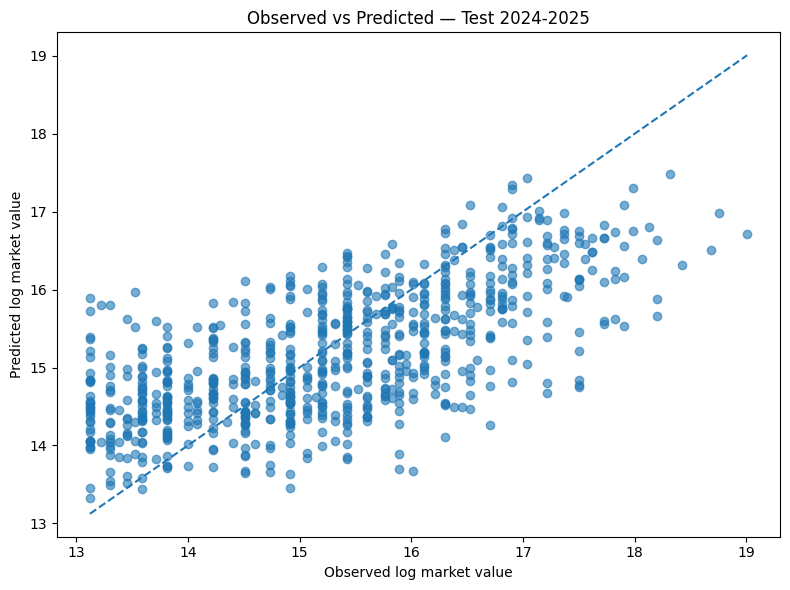

In [18]:
# Observado vs predicho en test
plt.figure(figsize=(8, 6))
plt.scatter(test_scored[TARGET], test_scored["predicted_log_market_value"], alpha=0.6)
min_val = min(test_scored[TARGET].min(), test_scored["predicted_log_market_value"].min())
max_val = max(test_scored[TARGET].max(), test_scored["predicted_log_market_value"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Observed log market value")
plt.ylabel("Predicted log market value")
plt.title("Observed vs Predicted — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_observed_vs_predicted_test.png", dpi=150)
plt.show()

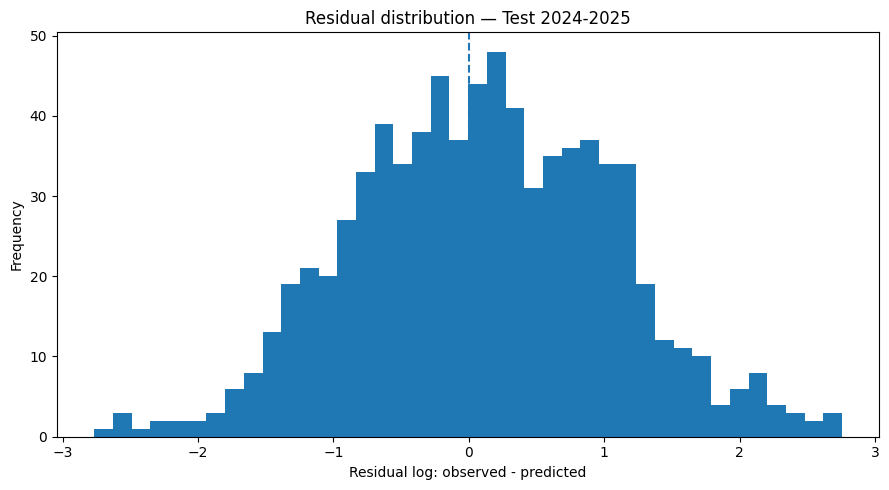

In [19]:
# Distribución de residuos en test
plt.figure(figsize=(9, 5))
plt.hist(test_scored["residual_log_observed_minus_predicted"], bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual log: observed - predicted")
plt.ylabel("Frequency")
plt.title("Residual distribution — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residual_distribution_test.png", dpi=150)
plt.show()

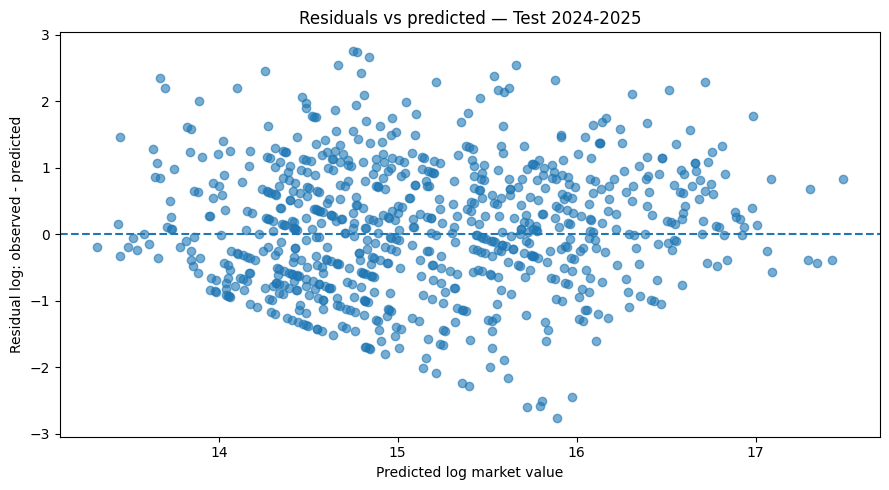

In [20]:
# Residuos vs predicción en test
plt.figure(figsize=(9, 5))
plt.scatter(test_scored["predicted_log_market_value"], test_scored["residual_log_observed_minus_predicted"], alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log market value")
plt.ylabel("Residual log: observed - predicted")
plt.title("Residuals vs predicted — Test 2024-2025")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_residuals_vs_predicted_test.png", dpi=150)
plt.show()

## 12. Inefficiency Score final

El Inefficiency Score se define como:

```text
valor estimado - valor observado
```

En este notebook se calcula sobre el test histórico para evaluar si el modelo econométrico genera señales razonables de infravaloración.

En la arquitectura actual del proyecto, el scoring operativo incorpora además:

- Growth Score;
- Confidence Score;
- Opportunity Score;
- Risk Score;
- Risk-adjusted Opportunity Score.

Por tanto, el score de este notebook debe interpretarse como antecedente metodológico del Scoring Engine completo.


In [21]:
# ============================================================
# 12. Rankings sobre test out-of-sample
# ============================================================

test_scored_final = scored[scored["split"] == "test"].copy()

ranking_cols = [c for c in [
    "player_id_tm", "player_id", "player_name", "club", "current_club_name_tm",
    "league", "season", "position_group", "age", "minutes_played",
    "market_value_eur", "predicted_market_value_eur",
    "market_value_gap_eur", "market_value_gap_pct",
    "log_market_value_eur", "predicted_log_market_value",
    "inefficiency_score", "inefficiency_score_z",
    "confidence_score", "opportunity_score",
    "matching_method", "matching_confidence", "age_diff", "club_score",
] if c in test_scored_final.columns]

undervalued_ranking = (
    test_scored_final
    .query("inefficiency_score > 0")
    .sort_values(["opportunity_score", "market_value_gap_eur"], ascending=False)
    [ranking_cols]
    .head(50)
    .copy()
)

overvalued_ranking = (
    test_scored_final
    .query("inefficiency_score < 0")
    .sort_values(["opportunity_score", "market_value_gap_eur"], ascending=True)
    [ranking_cols]
    .head(50)
    .copy()
)

undervalued_ranking.to_csv(OUTPUT_DIR / "03_undervalued_ranking.csv", index=False)
overvalued_ranking.to_csv(OUTPUT_DIR / "03_overvalued_ranking.csv", index=False)

display(undervalued_ranking.head(20))

,player_id_tm,player_name,club,current_club_name_tm,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,log_market_value_eur,predicted_log_market_value,inefficiency_score,inefficiency_score_z,confidence_score,opportunity_score,matching_method,matching_confidence,age_diff,club_score
3942,"512,352.0000",Lasse Rosenboom,Holstein Kiel,Holstein Kiel,Bundesliga,2024-2025,MID,22.9185,1734,"500,000.0000","7,955,479.2814","7,455,479.2814",14.9110,13.1224,15.8894,2.7670,2.8272,1.0000,2.8272,exact_age_club_validated,1.0000,0.9185,100.0000
4553,"948,273.0000",Mario Martín,Valladolid,Getafe Club de Fútbol S. A. D. Team Dubai,LaLiga,2024-2025,MID,20.6023,1748,"500,000.0000","6,723,855.7487","6,223,855.7487",12.4477,13.1224,15.7212,2.5988,2.6554,0.8500,2.2571,exact_age_validated,0.8500,0.6023,20.8333
4353,"610,608.0000",Dominik Javorček,Holstein Kiel,"SK Slavia Praha, a.s.",Bundesliga,2024-2025,DEF,22.1328,386,"550,000.0000","7,252,856.1386","6,702,856.1386",12.1870,13.2177,15.7969,2.5792,2.6354,0.8500,2.2401,exact_age_validated,0.8500,1.1328,31.2500
4249,"1,390,649.0000",Yan Diomandé,Leganés,RasenBallsport Leipzig,LaLiga,2024-2025,MID,18.4723,545,"600,000.0000","7,331,828.8647","6,731,828.8647",11.2197,13.3047,15.8077,2.5031,2.5575,0.8500,2.1739,exact_age_validated,0.8500,1.4723,41.3793
4085,"927,353.0000",Johan Manzambi,Freiburg,Sport-Club Freiburg,Bundesliga,2024-2025,MID,18.9870,335,"750,000.0000","8,640,660.3926","7,890,660.3926",10.5209,13.5278,15.9720,2.4442,2.4974,0.8500,2.1228,exact_age_validated,0.8500,0.9870,59.2593
4185,"1,061,336.0000",Pau Navarro,Villarreal,Villarreal Club de Fútbol S.A.D.,LaLiga,2024-2025,DEF,19.6496,916,"500,000.0000","4,859,177.6975","4,359,177.6975",8.7184,13.1224,15.3964,2.2740,2.3235,0.8500,1.9750,exact_age_validated,0.8500,0.6496,48.7805
4330,"807,688.0000",Yassin Belkhdim,Angers,Angers Sporting Club de l'Ouest,Ligue 1,2024-2025,MID,22.6448,1523,"500,000.0000","4,692,109.2027","4,192,109.2027",8.3842,13.1224,15.3614,2.2390,2.2878,0.8500,1.9446,exact_age_validated,0.8500,0.6448,32.4324
4596,"1,190,411.0000",Jesus Rodríguez,Real Betis,Calcio Como,LaLiga,2024-2025,MID,18.8966,1111,"700,000.0000","6,058,826.3406","5,358,826.3406",7.6555,13.4588,15.6170,2.1582,2.2052,0.8500,1.8744,exact_age_validated,0.8500,0.8966,19.0476
4583,"877,139.0000",Alberto costa,Juventus,Futebol Clube do Porto,Serie A,2024-2025,DEF,21.0267,357,"500,000.0000","4,045,706.4268","3,545,706.4268",7.0914,13.1224,15.2132,2.0908,2.1363,0.8500,1.8159,exact_age_validated,0.8500,1.0267,20.0000
4344,"743,496.0000",Kévin Danois,Auxerre,Association de la Jeunesse auxerroise,Ligue 1,2024-2025,MID,20.2765,1460,"500,000.0000","3,759,539.4082","3,259,539.4082",6.5191,13.1224,15.1398,2.0174,2.0614,0.8500,1.7522,exact_age_validated,0.8500,0.2765,31.8182


In [22]:
print("Top overvalued players — test")
display(overvalued_ranking.head(20))

Top overvalued players — test


,player_id_tm,player_name,club,current_club_name_tm,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,log_market_value_eur,predicted_log_market_value,inefficiency_score,inefficiency_score_z,confidence_score,opportunity_score,matching_method,matching_confidence,age_diff,club_score
3982,"810,092.0000",Warren Zaïre-Emery,Paris Saint-Germain,Paris Saint-Germain Football Club,Ligue 1,2024-2025,DEF,18.7598,2050,"60,000,000.0000","5,598,351.6752","-54,401,648.3248",-0.9067,17.9099,15.5380,-2.3719,-2.4235,1.0000,-2.4235,exact_age_club_validated,1.0000,0.7598,73.0769
4075,"974,982.0000",Ousmane Diomande,Sporting CP,Sporting Clube de Portugal,Liga Portugal,2024-2025,DEF,21.0431,2521,"40,000,000.0000","2,540,441.4506","-37,459,558.5494",-0.9365,17.5044,14.7478,-2.7565,-2.8165,0.8500,-2.3941,exact_age_validated,0.8500,1.0431,59.4595
4190,"650,568.0000",António Silva,Benfica,Sport Lisboa e Benfica,Liga Portugal,2024-2025,DEF,20.9418,2037,"40,000,000.0000","2,603,503.4915","-37,396,496.5085",-0.9349,17.5044,14.7724,-2.7320,-2.7915,0.8500,-2.3728,exact_age_validated,0.8500,0.9418,48.2759
4650,"565,424.0000",Johan Bakayoko,PSV,RasenBallsport Leipzig,Eredivisie,2024-2025,MID,21.6619,1579,"40,000,000.0000","2,782,499.4947","-37,217,500.5053",-0.9304,17.5044,14.8389,-2.6655,-2.7236,0.8500,-2.3150,exact_age_validated,0.8500,0.6619,16.0000
3986,"616,341.0000",Nuno Mendes,Paris Saint-Germain,Paris Saint-Germain Football Club,Ligue 1,2024-2025,DEF,22.4778,1676,"55,000,000.0000","6,080,060.2205","-48,919,939.7795",-0.8895,17.8228,15.6205,-2.2023,-2.2503,1.0000,-2.2503,exact_age_club_validated,1.0000,0.4778,73.0769
3962,"580,195.0000",Jamal Musiala,Bayern Munich,FC Bayern München,Bundesliga,2024-2025,MID,21.3908,1798,"130,000,000.0000","14,862,035.5584","-115,137,964.4416",-0.8857,18.6830,16.5143,-2.1687,-2.2159,1.0000,-2.2159,exact_age_club_validated,1.0000,0.3908,80.0000
4701,"473,169.0000",Brian Brobbey,Ajax,Sunderland Association Football Club,Eredivisie,2024-2025,ATT,22.8747,1555,"30,000,000.0000","2,346,292.4955","-27,653,707.5045",-0.9218,17.2167,14.6683,-2.5484,-2.6038,0.8500,-2.2133,exact_age_validated,0.8500,0.8747,10.0000
3963,"792,380.0000",Aleksandar Pavlovic,Bayern Munich,FC Bayern München,Bundesliga,2024-2025,MID,20.4353,1451,"50,000,000.0000","5,734,006.4044","-44,265,993.5956",-0.8853,17.7275,15.5619,-2.1656,-2.2128,1.0000,-2.2128,exact_age_club_validated,1.0000,0.4353,80.0000
4073,"646,740.0000",Gavi,Barcelona,Futbol Club Barcelona,LaLiga,2024-2025,MID,20.3943,1085,"80,000,000.0000","6,331,678.7125","-73,668,321.2875",-0.9209,18.1975,15.6611,-2.5365,-2.5917,0.8500,-2.2029,exact_age_validated,0.8500,1.3943,60.0000
4171,"847,278.0000",Karim Konaté,RB Salzburg,Fußballclub Red Bull Salzburg,Austrian Bundesliga,2024-2025,ATT,20.7420,753,"18,000,000.0000","1,555,025.3607","-16,444,974.6393",-0.9136,16.7059,14.2570,-2.4489,-2.5022,0.8500,-2.1269,exact_age_validated,0.8500,0.7420,50.0000


## 13. Análisis agregado del score

El análisis agregado permite comprobar si las señales de ineficiencia presentan patrones coherentes por:

- liga;
- posición;
- nivel de confianza;
- valor de mercado.

Estas lecturas son útiles para diagnóstico econométrico, pero no reemplazan la capa operativa de ranking introducida posteriormente.


In [23]:
# Asegurar que el subset de test incluye todas las columnas de scoring
test_scored_final = scored[scored["split"] == "test"].copy()

# Inefficiency por liga en test
league_score = (
    test_scored_final
    .groupby("league", dropna=False)
    .agg(
        n=("inefficiency_score", "size"),
        mean_inefficiency=("inefficiency_score", "mean"),
        median_inefficiency=("inefficiency_score", "median"),
        mean_gap_eur=("market_value_gap_eur", "mean"),
        median_gap_eur=("market_value_gap_eur", "median"),
        mean_gap_pct=("market_value_gap_pct", "mean"),
        mean_confidence=("confidence_score", "mean"),
        mean_opportunity=("opportunity_score", "mean"),
    )
    .reset_index()
    .sort_values("mean_inefficiency", ascending=False)
)

display(league_score)

league_score.to_csv(
    OUTPUT_DIR / "03_inefficiency_by_league_test.csv",
    index=False
)

,league,n,mean_inefficiency,median_inefficiency,mean_gap_eur,median_gap_eur,mean_gap_pct,mean_confidence,mean_opportunity
10,Spanish Segunda División,20,0.2738,0.2022,"127,683.9875","315,332.9124",0.7115,0.8500,0.2378
5,LaLiga,72,0.1252,0.2147,"-7,867,775.3372","1,154,495.9218",1.0599,0.8604,0.1109
9,Serie A,77,-0.0299,-0.0535,"-2,361,053.1357","-390,710.7059",0.4219,0.8539,-0.0260
1,Belgian Pro League,111,-0.0629,-0.0824,"-830,572.8353","-174,070.8692",0.2163,0.8527,-0.0531
6,Liga Portugal,60,-0.0795,0.1655,"-2,622,044.3096","308,076.5216",0.4256,0.8525,-0.0686
2,Bundesliga,77,-0.1054,-0.2189,"-8,156,312.7298","-1,552,738.2787",0.6336,0.8792,-0.0937
4,Eredivisie,93,-0.1381,-0.1057,"-2,253,427.4622","-100,274.3429",0.3146,0.8629,-0.1110
7,Ligue 1,99,-0.1446,-0.2238,"-5,166,120.3126","-1,084,113.5521",0.4696,0.8682,-0.1400
0,Austrian Bundesliga,48,-0.1875,0.0791,"-1,887,639.7141","85,290.0119",0.2463,0.8531,-0.1608
3,Championship,45,-0.2682,-0.3504,"-2,416,538.8742","-1,217,098.5778",0.2482,0.8533,-0.2303


In [24]:
# Re-crear subsets después de calcular todos los scores
train_scored = scored[scored["split"] == "train"].copy()
test_scored = scored[scored["split"] == "test"].copy()

required_scoring_cols = [
    "inefficiency_score",
    "inefficiency_score_z",
    "confidence_score",
    "opportunity_score",
]

missing_cols = [c for c in required_scoring_cols if c not in test_scored.columns]

if missing_cols:
    raise KeyError(f"Missing scoring columns in test_scored: {missing_cols}")

print("Scoring subsets actualizados correctamente")
print(f"Train scored: {train_scored.shape}")
print(f"Test scored: {test_scored.shape}")

Scoring subsets actualizados correctamente
Train scored: (3940, 68)
Test scored: (776, 68)


## 14. Robustness check con matching estricto

Este robustness check evalúa si los resultados son sensibles a la calidad del matching.

Se restringe la muestra a observaciones con mayor confianza de integración.

Interpretación:

- si la muestra estricta mantiene resultados similares, aumenta la confianza metodológica;
- si mejora sustancialmente, puede indicar que el ruido de matching penaliza el modelo;
- si empeora, puede reflejar pérdida de cobertura o sesgo de selección.

En Sprint 10, esta lógica se complementa con Confidence Score y Risk Score dentro de la Current Scouting Layer.


In [25]:
# ============================================================
# 13. Robustness check: matching estricto
# ============================================================

strict_df = model_df.copy()

if "matching_confidence" in strict_df.columns:
    strict_df = strict_df[pd.to_numeric(strict_df["matching_confidence"], errors="coerce") >= 0.99]

if "age_diff" in strict_df.columns:
    strict_df = strict_df[pd.to_numeric(strict_df["age_diff"], errors="coerce") <= 1.0]

if "matching_method" in strict_df.columns:
    strict_df = strict_df[strict_df["matching_method"].isin([
        "exact_age_validated",
        "exact_age_club_validated",
        "fuzzy_age_club_validated",
    ])]

strict_train = strict_df[strict_df["season"].isin(TRAIN_SEASONS)].copy()
strict_test = strict_df[strict_df["season"] == TEST_SEASON].copy()

print(f"Strict rows: {len(strict_df):,}")
print(f"Strict train rows: {len(strict_train):,}")
print(f"Strict test rows: {len(strict_test):,}")

if len(strict_train) >= 50 and len(strict_test) >= 20:
    strict_model, X_strict_train = fit_ols_hc3(strict_train, final_numeric_features, final_categorical_features)
    strict_pred_test = predict_with_design(strict_model, strict_test, X_strict_train, final_numeric_features, final_categorical_features)
    strict_metrics = pd.DataFrame([
        regression_metrics(strict_test[TARGET], strict_pred_test, "M3_strict_matching", "test")
    ])
    display(strict_metrics)
    strict_metrics.to_csv(OUTPUT_DIR / "03_strict_matching_metrics.csv", index=False)
else:
    print("Muestra estricta demasiado pequeña para estimar un modelo robusto comparable.")


Strict rows: 249
Strict train rows: 150
Strict test rows: 44


,model,split,n,MAE_log,RMSE_log,R2
0,M3_strict_matching,test,44,0.8550,1.1079,0.5130


## 15. Conclusiones para la memoria del TFM

Este notebook consolida la evaluación econométrica de la expansión multi-liga desarrollada durante Sprint 13A.1 y sitúa correctamente esta fase dentro de la arquitectura analítica del proyecto.

La principal aportación metodológica de Sprint 13A.1 consiste en evaluar el impacto de la ampliación del universo modelizable desde siete hasta once ligas europeas, manteniendo constantes la metodología econométrica, las variables utilizadas y la estrategia de validación temporal.

La comparación se realiza entre:

```text
Baseline Dataset
(7 ligas)
↓
3.916 observaciones
↓
2.138 jugadores
```

y

```text
Multi-League Dataset
(11 ligas)
↓
5.527 observaciones
↓
2.867 jugadores
```

manteniendo la misma separación temporal:

* Train: 2019-2020 → 2023-2024.
* Test: 2024-2025.
* Current Scouting: 2025-2026, excluida de la validación.

Conclusiones principales:

1. La expansión multi-liga incrementa significativamente el tamaño del dataset modelizable, aumentando las observaciones un 41,1% y los jugadores únicos un 34,1%.
2. La incorporación de Championship, Belgian Pro League, Austrian Bundesliga y Spanish Segunda División incrementa la diversidad competitiva y económica del universo analizado.
3. La distribución temporal y posicional permanece estable tras la expansión, lo que indica que el crecimiento del dataset no introduce desequilibrios estructurales relevantes.
4. La distribución del valor de mercado se desplaza hacia valores inferiores, reflejando la incorporación de mercados secundarios con menor valoración media.
5. El modelo econométrico mantiene capacidad explicativa y generaliza correctamente al nuevo universo competitivo, aunque con una reducción moderada del rendimiento predictivo respecto al baseline de siete ligas.
6. La disminución observada en R² sugiere que la ampliación de cobertura introduce mayor heterogeneidad estructural, aumentando la complejidad del problema de estimación.
7. Los efectos de liga y posición continúan capturando diferencias relevantes entre mercados y perfiles de jugador.
8. El Inefficiency Score econométrico sigue proporcionando una medida interpretable de discrepancias entre valor observado y valor esperado.

Comparación conceptual:

```text
Econometría
=
interpretabilidad
+
benchmark metodológico
+
análisis de generalización

Machine Learning
=
mayor capacidad predictiva
+
adaptación a entornos heterogéneos
+
scoring operativo
```

La evidencia obtenida durante Sprint 13A.1 indica que la expansión multi-liga mejora sustancialmente la cobertura del sistema, pero incrementa la heterogeneidad competitiva y económica del universo analizado. Como consecuencia, los modelos lineales experimentan una reducción moderada de rendimiento, reforzando la necesidad de técnicas más flexibles para capturar relaciones no lineales presentes en mercados futbolísticos diversos.

Desde la perspectiva del TFM, este resultado constituye una evidencia directa sobre la validez externa de la metodología y proporciona una base sólida para las siguientes fases de investigación.

En particular, Sprint 13A.1 establece el punto de partida para evaluar si modelos de Machine Learning más complejos son capaces de absorber la heterogeneidad introducida por la expansión multi-liga y mantener niveles elevados de capacidad predictiva.

Dentro de la arquitectura global del proyecto, este notebook representa la transición entre:

```text
External Validity Assessment
```

y

```text
Multi-League Predictive Evaluation
```

como parte de una plataforma integral de Football Analytics, Recruitment Intelligence y Decision Support Systems aplicada al mercado de fichajes profesionales.


## 16. Próximos pasos

La evaluación econométrica multi-liga desarrollada durante Sprint 13A.1 constituye una etapa intermedia dentro de la validación de la arquitectura analítica del proyecto.

Los siguientes pasos metodológicos se centran en determinar si modelos más flexibles son capaces de absorber la heterogeneidad adicional introducida por la expansión desde siete hasta once ligas europeas.

### 1. Evaluación Machine Learning Multi-Liga

Reentrenar los modelos de Machine Learning sobre:

```text
player_season_modeling_v13a.parquet
```

Objetivos:

* comparar rendimiento frente al benchmark econométrico;
* evaluar robustez predictiva en entornos competitivos más diversos;
* medir el impacto de la expansión multi-liga sobre modelos no lineales.

---

### 2. Comparación de generalización

Comparar resultados entre:

```text
Baseline Dataset (7 ligas)
↓
Econometría
↓
Machine Learning
```

y

```text
Multi-League Dataset (11 ligas)
↓
Econometría
↓
Machine Learning
```

Métricas principales:

* MAE;
* RMSE;
* R²;
* estabilidad de rankings;
* cobertura competitiva.

---

### 3. Evaluación de Opportunity Detection

Analizar el impacto de la expansión multi-liga sobre:

* Inefficiency Score;
* Opportunity Score;
* distribución de oportunidades por liga;
* representación de ligas secundarias en rankings finales.

---

### 4. Evaluación de Recruitment Intelligence

Determinar si la ampliación del universo competitivo modifica:

* shortlists de scouting;
* rankings ejecutivos;
* perfiles identificados como oportunidades de mercado.

---

### 5. Sprint 13B — Advanced Data Expansion

Una vez aislado el efecto de la expansión multi-liga, la siguiente fase de investigación incorporará nuevas fuentes y métricas avanzadas.

Líneas previstas:

#### FBref Advanced Metrics

* Shooting
* Passing
* Pass Types
* Goal & Shot Creation
* Possession
* Defensive Actions

#### Understat Integration

* xG
* xA
* xGChain
* xGBuildup

Objetivo:

Incrementar la profundidad analítica del sistema y evaluar si la incorporación de métricas avanzadas mejora la capacidad predictiva y la detección de ineficiencias de mercado.

---

### 6. Validación integral de la arquitectura

La combinación de Sprint 13A.1 y Sprint 13B permitirá responder a dos preguntas de investigación complementarias:

```text
¿La metodología generaliza correctamente a mercados y ecosistemas competitivos distintos?
```

y

```text
¿La incorporación de métricas avanzadas mejora la capacidad predictiva y la identificación de oportunidades?
```

Estas dos fases constituyen la continuación natural del proceso de validación metodológica de la plataforma y proporcionan la base para futuras extensiones del sistema de Football Analytics, Recruitment Intelligence y Decision Support desarrollado en este proyecto.

